# Assignment 2
## FINA 60201A - Fixed-income 
### Ludwig Casaubon 
### Yueheng Shao 

# **Data availability.**
Part 1 uses licensed WRDS, Compustat, and CRSP data that are not redistributed in this public repository. The notebook is provided with its computed outputs. Public Federal Reserve data are retrieved directly from their source when required.

# PART ONE
The objective is to compute the term structure of credit spreads for the company Johnson &
Johnson (GVKEY 006266, PERMCO 21018, PERMNO 22111).

In [1]:
# packages
import numpy as np
import pandas as pd
from scipy.optimize import brentq
from scipy.stats import norm
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

1] From Compustat Fundamentals Quarterly, download the series of long-term debt (𝐷𝐿𝑇𝑇𝑄𝑡)
and debt in current liabilities (𝐷𝐿𝐶𝑄𝑡) from 2024Q4 to 2025Q4. Use a linear interpolation to
construct the daily series for 𝐿𝑡 ≔ 𝐷𝐿𝐶𝑄𝑡 + 0.5𝐷𝐿𝑇𝑇𝑄𝑡.

In [2]:
# import data
df = pd.read_csv("q1_1data_raw.csv")

# data clean
df.columns = df.columns.str.lower()
df["datadate"] = pd.to_datetime(df["datadate"])

# 2024q4 to 2025q4
df = df[
    (df["datadate"] >= "2024-12-31") &
    (df["datadate"] <= "2025-12-31")
    ].copy()

df = df.sort_values("datadate").reset_index(drop=True)

# construct quarterly Lt
df["L"] = df["dlcq"] + 0.5 * df["dlttq"]

print("Quarterly Lt:")
print(df[["datadate", "datafqtr", "dlcq", "dlttq", "L"]])

# create daily date range for daily series
daily_dates = pd.date_range(
    start=df["datadate"].min(),
    end=df["datadate"].max(),
    freq="D"
    )

daily_df = pd.DataFrame({"date": daily_dates})


# merge quarterly Lt onto daily grid
daily_df = daily_df.merge(
    df[["datadate", "L"]],
    how="left",
    left_on="date",
    right_on="datadate"
)

daily_df = daily_df.drop(columns="datadate")


# linear interpolation
daily_df["L"] = daily_df["L"].interpolate(method="linear")

print("\nDaily interpolated Lt:")
print(daily_df.head(10))
print(daily_df.tail(10))


# save output
daily_df.to_csv("cleaned_q1_daily_L.csv", index=False)
print("\nSaved file: cleaned_q1_daily_L.csv")

Quarterly Lt:
    datadate datafqtr     dlcq    dlttq        L
0 2024-12-31   2024Q4   5983.0  30651.0  21308.5
1 2025-03-31   2025Q1  13897.0  38355.0  33074.5
2 2025-06-30   2025Q2  11526.0  39235.0  31143.5
3 2025-09-30   2025Q3   6387.0  39408.0  26091.0
4 2025-12-31   2025Q4   8495.0  39438.0  28214.0

Daily interpolated Lt:
        date             L
0 2024-12-31  21308.500000
1 2025-01-01  21439.233333
2 2025-01-02  21569.966667
3 2025-01-03  21700.700000
4 2025-01-04  21831.433333
5 2025-01-05  21962.166667
6 2025-01-06  22092.900000
7 2025-01-07  22223.633333
8 2025-01-08  22354.366667
9 2025-01-09  22485.100000
          date             L
356 2025-12-22  28006.315217
357 2025-12-23  28029.391304
358 2025-12-24  28052.467391
359 2025-12-25  28075.543478
360 2025-12-26  28098.619565
361 2025-12-27  28121.695652
362 2025-12-28  28144.771739
363 2025-12-29  28167.847826
364 2025-12-30  28190.923913
365 2025-12-31  28214.000000

Saved file: cleaned_q1_daily_L.csv


2] From CRSP, obtain the daily time series of market capitalization.

In [3]:
df_2 = pd.read_csv("q1_2crsp_raw.csv")

print("\the daily time series of market capitalization:")
print(df_2.head(10))
print(df_2.tail(10))

	he daily time series of market capitalization:
   PERMNO  HdrCUSIP Ticker  PERMCO    DlyCalDt  DlyPrc        DlyCap   ShrOut
0   22111  47816010    JNJ   21018  2024-09-03  167.16  4.023949e+08  2407244
1   22111  47816010    JNJ   21018  2024-09-04  167.36  4.028764e+08  2407244
2   22111  47816010    JNJ   21018  2024-09-05  164.99  3.971712e+08  2407244
3   22111  47816010    JNJ   21018  2024-09-06  164.38  3.957028e+08  2407244
4   22111  47816010    JNJ   21018  2024-09-09  166.61  4.010709e+08  2407244
5   22111  47816010    JNJ   21018  2024-09-10  167.38  4.029245e+08  2407244
6   22111  47816010    JNJ   21018  2024-09-11  164.82  3.967620e+08  2407244
7   22111  47816010    JNJ   21018  2024-09-12  164.64  3.963287e+08  2407244
8   22111  47816010    JNJ   21018  2024-09-13  165.52  3.984470e+08  2407244
9   22111  47816010    JNJ   21018  2024-09-16  166.99  4.019857e+08  2407244
     PERMNO  HdrCUSIP Ticker  PERMCO    DlyCalDt  DlyPrc        DlyCap  \
324   22111  4781601

3] Apply the iterative approach to estimate the asset value and volatility by the end of 2025. Use
the daily one-year zero-coupon yield from the St-Louis Fed as the risk-free rate. Make sure the
trading days coincide between the market capitalization and the risk-free rate.

In [4]:
# load data (rename for convenience)

L_df = pd.read_csv("cleaned_q1_daily_L.csv")
crsp_df = pd.read_csv("q1_2crsp_raw.csv")
# Public FRED series: fitted 1-year zero-coupon Treasury yield
FRED_1Y_URL = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=THREEFY1"

rf_df = pd.read_csv(FRED_1Y_URL)

date_col = "observation_date" if "observation_date" in rf_df.columns else "DATE"
rf_df = rf_df.rename(columns={date_col: "observation_date"})
rf_df["observation_date"] = pd.to_datetime(rf_df["observation_date"])

##############
# data clean #
##############
# clean dates and keep 2025 only

L_df["date"] = pd.to_datetime(L_df["date"])
crsp_df["DlyCalDt"] = pd.to_datetime(crsp_df["DlyCalDt"])
rf_df["observation_date"] = pd.to_datetime(rf_df["observation_date"])


L_df = L_df[(L_df["date"] >= "2025-01-01") & (L_df["date"] <= "2025-12-31")].copy()
crsp_df = crsp_df[(crsp_df["DlyCalDt"] >= "2025-01-01") & (crsp_df["DlyCalDt"] <= "2025-12-31")].copy()
rf_df = rf_df[(rf_df["observation_date"] >= "2025-01-01") & (rf_df["observation_date"] <= "2025-12-31")].copy()


# clean market capitalization
# dlycap should be y in thousands of dollars in CRSP but compustat debt variables are usually in millions of dollars. 
# -> divide by 1000 to convert equity into millions.

crsp_df["E"] = pd.to_numeric(crsp_df["DlyCap"], errors="coerce") / 1000
equity_df = crsp_df[["DlyCalDt", "E"]].rename(columns={"DlyCalDt": "date"}).copy()


# risk-free rate from fed

rf_df["THREEFY1"] = pd.to_numeric(rf_df["THREEFY1"], errors="coerce")/100

rf_df = rf_df.rename(columns={
    "observation_date": "date",
    "THREEFY1": "rf"
})

# merge 

df = (
    equity_df
    .merge(L_df, on="date", how="inner")
    .merge(rf_df[["date", "rf"]], on="date", how="inner")
    .dropna()
    .sort_values("date")
    .reset_index(drop=True)
)

print("Number of coincident trading days:", len(df))
print(df.head())

Number of coincident trading days: 248
        date             E             L        rf
0 2025-01-02  346745.86446  21569.966667  0.042491
1 2025-01-03  347155.16037  21700.700000  0.042579
2 2025-01-06  345879.12018  22092.900000  0.042569
3 2025-01-07  352066.71129  22223.633333  0.042682
4 2025-01-08  342532.52421  22354.366667  0.042619


In [5]:
# initial asset volatility
df["equity_ret"] = np.log(df["E"] / df["E"].shift(1))
sigma_E = df["equity_ret"].std(ddof=1) * np.sqrt(252)

print("Initial annualized equity volatility =", sigma_E)

Initial annualized equity volatility = 0.19772000705853326


In [6]:
# set up for Merton

T = 1.0

def equity_from_asset(V, F, r, sigma_V, T=1):
    if V <= 0 or F <= 0 or sigma_V <= 0:
        return np.nan
    
    d1 = (np.log(V / F) + (r + 0.5 * sigma_V**2) * T) / (sigma_V * np.sqrt(T))
    d2 = d1 - sigma_V * np.sqrt(T)
    
    E = V * norm.cdf(d1) - F * np.exp(-r * T) * norm.cdf(d2)
    return E

def solve_asset_value(E_obs, F, r, sigma_V, T=1):
    def f(V):
        return equity_from_asset(V, F, r, sigma_V, T) - E_obs

    lower = max(E_obs, 1e-8)
    upper = max(E_obs + F, 2 * E_obs + F, 1)

    f_low = f(lower)
    f_up = f(upper)

    count = 0
    while np.isnan(f_up) or f_low * f_up > 0:
        upper *= 2
        f_up = f(upper)
        count += 1
        if count > 100:
            raise ValueError("Could not bracket root for asset value.")

    return brentq(f, lower, upper)


# initial guess for asset volatility
sigma_V = sigma_E * (df["E"] / (df["E"] + df["L"])).mean()
print("Initial annualized asset volatility guess =", sigma_V)

Initial annualized asset volatility guess = 0.18455231884183534


In [7]:
# iterative approach to estimate

tol = 1e-6
max_iter = 200

for it in range(max_iter):
    V_list = []

    for _, row in df.iterrows():
        E_obs = row["E"]
        F = row["L"]
        r = row["rf"]

        V_t = solve_asset_value(E_obs, F, r, sigma_V, T)
        V_list.append(V_t)

    df["V"] = V_list
    df["asset_ret"] = np.log(df["V"] / df["V"].shift(1))
    sigma_V_new = df["asset_ret"].std(ddof=1) * np.sqrt(252)

    diff = abs(sigma_V_new - sigma_V)
    print(f"Iteration {it+1}: sigma_V = {sigma_V_new:.8f}, diff = {diff:.8e}")

    if diff < tol:
        sigma_V = sigma_V_new
        break

    sigma_V = sigma_V_new


# result 

df_final = df.dropna().copy()
last_row = df_final.iloc[-1]

V_end_2025 = last_row["V"]
sigma_V_end_2025 = sigma_V


print("Last trading day:", last_row["date"].date())
print(f"Estimated asset value at end of 2025    = {V_end_2025:,.6f} million")
print(f"Estimated asset volatility (annualized) = {sigma_V_end_2025:.6f}")



# save outputs

q3_output = df[["date", "E", "L", "rf", "V"]].copy()
q3_output.to_csv("q3_asset_estimation_output.csv", index=False)

q3_summary = pd.DataFrame({
    "last_date": [last_row["date"]],
    "V_end_2025_million": [V_end_2025],
    "sigma_V_annualized": [sigma_V_end_2025],
    "n_obs": [len(df_final)]
})

q3_summary.to_csv("q3_summary.csv", index=False)



Iteration 1: sigma_V = 0.18477132, diff = 2.19004493e-04
Iteration 2: sigma_V = 0.18477132, diff = 0.00000000e+00
Last trading day: 2025-12-31
Estimated asset value at end of 2025    = 525,844.494482 million
Estimated asset volatility (annualized) = 0.184771


4] Assuming that 𝐿𝑡 and 𝐷𝐿𝑇𝑇𝑄𝑡 are the default points at the one- and twenty-year horizons,
respectively, use a linear inter- and extrapolation to construct the default frontier for all maturities
between 0 and 30 years.

In [8]:
# Reload data required for the default-frontier construction

L_df = pd.read_csv("cleaned_q1_daily_L.csv")
raw_q1_df = pd.read_csv("q1_1data_raw.csv")


# data clean

L_df["date"] = pd.to_datetime(L_df["date"])
raw_q1_df["datadate"] = pd.to_datetime(raw_q1_df["datadate"])

# L_t on 2025-12-31
L_end_2025 = L_df.loc[L_df["date"] == "2025-12-31", "L"].iloc[0]

# DLTTQ on 2025Q4
DLTTQ_end_2025 = raw_q1_df.loc[raw_q1_df["datafqtr"] == "2025Q4", "dlttq"].iloc[0]

print("L(2025-12-31)      =", L_end_2025)
print("DLTTQ(2025Q4)      =", DLTTQ_end_2025)

L(2025-12-31)      = 28214.0
DLTTQ(2025Q4)      = 39438.0


In [9]:
# define the two anchor points

T1 = 1
F1 = L_end_2025

T2 = 20
F2 = DLTTQ_end_2025

# slope of the straight line
slope = (F2 - F1) / (T2 - T1)

print("Slope =", slope)

Slope = 590.7368421052631


In [10]:
# construct default frontier F(T)

# Linear interpolation / extrapolation:
# F(T) = F1 + slope * (T - T1)

def default_frontier(T):
    T = np.asarray(T, dtype=float)
    return F1 + slope * (T - T1)


# maturity grid from 0 to 30 years

T_grid = np.linspace(0, 30, 301)   # every 0.1 year
F_grid = default_frontier(T_grid)


#results

frontier_df = pd.DataFrame({
    "maturity_years": T_grid,
    "default_frontier": F_grid
})

print(frontier_df.head())
print(frontier_df.tail())

   maturity_years  default_frontier
0             0.0      27623.263158
1             0.1      27682.336842
2             0.2      27741.410526
3             0.3      27800.484211
4             0.4      27859.557895
     maturity_years  default_frontier
296            29.6      45109.073684
297            29.7      45168.147368
298            29.8      45227.221053
299            29.9      45286.294737
300            30.0      45345.368421


In [11]:
# maturities
key_T = np.array([0, 1, 2, 5, 10, 20, 30], dtype=float)
key_F = default_frontier(key_T)

key_df = pd.DataFrame({
    "maturity_years": key_T,
    "default_frontier": key_F
})

print("Default frontier at key maturities:")
print(key_df)

Default frontier at key maturities:
   maturity_years  default_frontier
0             0.0      27623.263158
1             1.0      28214.000000
2             2.0      28804.736842
3             5.0      30576.947368
4            10.0      33530.631579
5            20.0      39438.000000
6            30.0      45345.368421


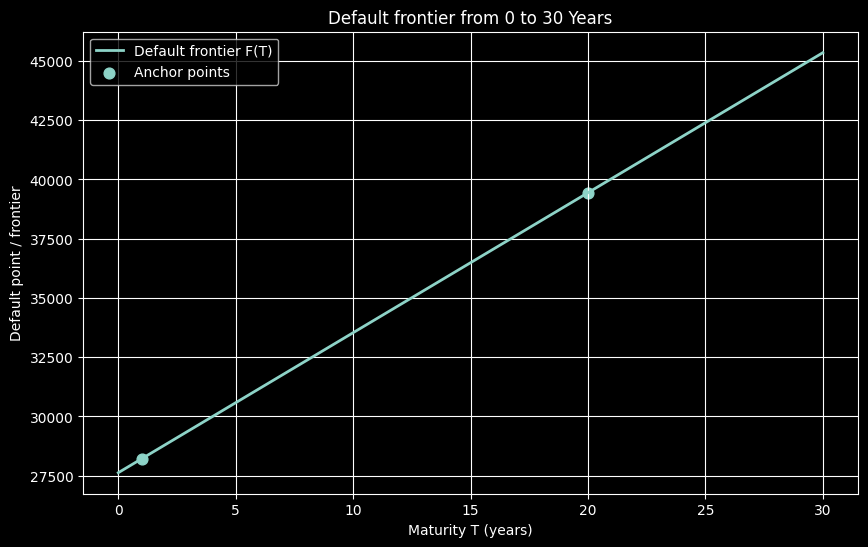

In [12]:
# plot
plt.figure(figsize=(10, 6))
plt.plot(T_grid, F_grid, linewidth=2, label="Default frontier F(T)")
plt.scatter([T1, T2], [F1, F2], s=60, label="Anchor points")

plt.xlabel("Maturity T (years)")
plt.ylabel("Default point / frontier")
plt.title("Default frontier from 0 to 30 Years")
plt.legend()
plt.grid(True)
plt.show()


# save outputs
frontier_df.to_csv("q4_default_frontier_full.csv", index=False)
key_df.to_csv("q4_default_frontier_key_maturities.csv", index=False)

summary_q4 = pd.DataFrame({
    "L_end_2025": [L_end_2025],
    "DLTTQ_2025Q4": [DLTTQ_end_2025],
    "T1": [T1],
    "F1": [F1],
    "T2": [T2],
    "F2": [F2],
    "slope": [slope]
})

summary_q4.to_csv("q4_default_frontier_summary.csv", index=False)



5] On the first trading day of 2026, apply the Merton model to compute the term structure of
credit spreads (up to 30 years). Use the zero-coupon yields from the St-Louis Fed as the risk-free
rates

In [13]:
# Utilities for automatic Federal Reserve data download
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from pathlib import Path
from io import StringIO
import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry



# Paths
FED_CSV_URL = "https://www.federalreserve.gov/data/yield-curve-tables/feds200628.csv"
FED_LOCAL_CSV = "fed_nominal_yield_curve.csv"


# CSV download
def build_retry_session():
    retry = Retry(
        total=5,
        connect=5,
        read=5,
        backoff_factor=1.0,
        status_forcelist=[429, 500, 502, 503, 504],
        allowed_methods=["GET"],
        raise_on_status=False,
    )
    session = requests.Session()
    adapter = HTTPAdapter(max_retries=retry)
    session.mount("https://", adapter)
    session.mount("http://", adapter)
    session.headers.update({
        "User-Agent": (
            "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
            "AppleWebKit/537.36 (KHTML, like Gecko) "
            "Chrome/122.0 Safari/537.36"
        ),
        "Accept": "text/csv,application/csv,text/plain,*/*",
        "Referer": "https://www.federalreserve.gov/data/nominal-yield-curve.htm",
        "Connection": "keep-alive",
    })
    return session

def download_fed_csv(url=FED_CSV_URL, local_path=FED_LOCAL_CSV, timeout=(10, 120)):
    session = build_retry_session()
    resp = session.get(url, timeout=timeout)
    resp.raise_for_status()

    path = Path(local_path)
    path.write_bytes(resp.content)

    if not path.exists() or path.stat().st_size == 0:
        raise RuntimeError()
    

    return path


# CSV reading
def read_fed_nominal_curve_csv(local_path=FED_LOCAL_CSV):

    path = Path(local_path)
    if not path.exists():
        raise FileNotFoundError()

    raw_text = path.read_text(encoding="utf-8-sig", errors="replace")

    lines = raw_text.splitlines()
    header_idx = None

    for i, line in enumerate(lines):
        if line.startswith("Date,"):
            header_idx = i
            break

    if header_idx is None:
        raise ValueError("Could not find the CSV header.")

    clean_csv = "\n".join(lines[header_idx:])
    df = pd.read_csv(StringIO(clean_csv))

    df.columns = [str(c).strip() for c in df.columns]

    # Nelson-Siegel-Svensson parameters
    nss_cols = [
        "BETA0",
        "BETA1",
        "BETA2",
        "BETA3",
        "TAU1",
        "TAU2",
    ]

    # Zero-coupon yields from 1 to 30 years
    sven_cols = [f"SVENY{i:02d}" for i in range(1, 31)]

    required_cols = nss_cols + sven_cols
    missing_cols = [c for c in required_cols if c not in df.columns]

    if missing_cols:
        raise ValueError(
            f"Missing Federal Reserve columns: {missing_cols}"
        )

    df["date"] = pd.to_datetime(df["Date"], errors="coerce")

    # Convert all NSS parameters and yields to numeric values
    for c in required_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    df = (
        df
        .dropna(subset=["date"])
        .sort_values("date")
        .reset_index(drop=True)
    )

    return df[["date"] + nss_cols + sven_cols]
# 2026 curve
def load_first_2026_zero_coupon_curve_from_local(local_path=FED_LOCAL_CSV):
    df = read_fed_nominal_curve_csv(local_path)
    sven_cols = [f"SVENY{i:02d}" for i in range(1, 31)]

    df_2026 = df.loc[df["date"] >= pd.Timestamp("2026-01-01")].copy()
    if df_2026.empty:
        raise ValueError()

    ok = df_2026[sven_cols].notna().all(axis=1)
    df_2026 = df_2026.loc[ok].copy()

    if df_2026.empty:
        raise ValueError()

    first_date = df_2026["date"].iloc[0]
    row = df_2026.iloc[0]

    rf_curve = pd.DataFrame({
        "maturity_years": np.arange(1, 31, dtype=float),
        "rf_zc_yield": row[sven_cols].to_numpy(dtype=float) / 100.0
    })

    return first_date, rf_curve

# downlaod fed CSV
try:
    csv_path = download_fed_csv()
except Exception as e:
    raise RuntimeError() from e

first_trade_date_2026, rf_curve_obs = load_first_2026_zero_coupon_curve_from_local(FED_LOCAL_CSV)

print("first trading day 2026 :", first_trade_date_2026.date())

first trading day 2026 : 2026-01-02


In [14]:
# from q3

V0 = V_end_2025
sigma_V = sigma_V_end_2025

print("V0 from Q3 =", V0)
print("sigma_V from Q3 =", sigma_V)

# from q4

F1 = L_end_2025
F20 = DLTTQ_end_2025

T1 = 1.0
T2 = 20.0

print("F(1) from Q4 =", F1)
print("F(20) from Q4 =", F20)

V0 from Q3 = 525844.4944822636
sigma_V from Q3 = 0.18477132333498095
F(1) from Q4 = 28214.0
F(20) from Q4 = 39438.0


In [15]:

slope_F = (F20 - F1) / (T2 - T1)

def default_frontier(T):
    T = np.asarray(T, dtype=float)
    return F1 + slope_F * (T - T1)

# import data: Fed nominal zero-coupon yield curve (SVENYXX)
rf_df = pd.read_csv("fed_nominal_yield_curve.csv", skiprows=9)
rf_df["Date"] = pd.to_datetime(rf_df["Date"])

yield_cols = [f"SVENY{i:02d}" for i in range(1, 31)]

# make sure all data are numeric
for col in yield_cols:
    rf_df[col] = pd.to_numeric(rf_df[col], errors="coerce")


# select the first valid trading day of 2026
rf_2026 = rf_df[rf_df["Date"] >= "2026-01-01"].copy()
rf_2026 = rf_2026.sort_values("Date").reset_index(drop=True)

rf_valid = rf_2026.dropna(subset=yield_cols).copy()

if len(rf_valid) == 0:
    raise ValueError("No valid zero-coupon Treasury curve found in early 2026.")

row0 = rf_valid.iloc[0]
curve_date = row0["Date"]

print("First valid trading day used =", curve_date.date())



First valid trading day used = 2026-01-02


In [16]:



# Build risk-free curve from SVENY01 ... SVENY30
maturity_map = {f"SVENY{i:02d}": float(i) for i in range(1, 31)}

curve = pd.DataFrame({
    "fred_code": list(maturity_map.keys()),
    "maturity_years": [maturity_map[k] for k in maturity_map.keys()],
    "rf_percent": [row0[k] for k in maturity_map.keys()]
})

curve["rf_decimal"] = curve["rf_percent"] / 100.0

print("Risk-free zero-coupon curve used:")
print(curve)

# # Build risk-free curve
# curve = pd.DataFrame({
#     "maturity_years": [1, 2, 3, 5, 7, 10],
#     "zc_raw": [row0["z1"], row0["z2"], row0["z3"], row0["z5"], row0["z7"], row0["z10"]]
# })



# if curve["zc_raw"].max() > 1:
#     curve["zc_decimal"] = curve["zc_raw"] / 100.0
# else:
#     curve["zc_decimal"] = curve["zc_raw"]

# print("Zero-coupon risk-free curve used:")
# print(curve)

Risk-free zero-coupon curve used:
   fred_code  maturity_years  rf_percent  rf_decimal
0    SVENY01             1.0      3.4986    0.034986
1    SVENY02             2.0      3.4727    0.034727
2    SVENY03             3.0      3.5211    0.035211
3    SVENY04             4.0      3.6094    0.036094
4    SVENY05             5.0      3.7178    0.037178
5    SVENY06             6.0      3.8344    0.038344
6    SVENY07             7.0      3.9524    0.039524
7    SVENY08             8.0      4.0677    0.040677
8    SVENY09             9.0      4.1781    0.041781
9    SVENY10            10.0      4.2822    0.042822
10   SVENY11            11.0      4.3793    0.043793
11   SVENY12            12.0      4.4692    0.044692
12   SVENY13            13.0      4.5519    0.045519
13   SVENY14            14.0      4.6274    0.046274
14   SVENY15            15.0      4.6960    0.046960
15   SVENY16            16.0      4.7579    0.047579
16   SVENY17            17.0      4.8136    0.048136
17   SVENY18

In [17]:
# interpolate risk-free rates
rf_interp = interp1d(
    curve["maturity_years"],
    curve["rf_decimal"],
    kind="linear",
    fill_value="extrapolate"
)

# Merton

def merton_debt_value(V0, F, r, sigma_V, T):
    d1 = (np.log(V0 / F) + (r + 0.5 * sigma_V**2) * T) / (sigma_V * np.sqrt(T))
    d2 = d1 - sigma_V * np.sqrt(T)
    D = V0 * norm.cdf(-d1) + F * np.exp(-r * T) * norm.cdf(d2)
    return D

# build the term structure

T_grid = np.linspace(1.0, 30.0, 291)

rf_grid = rf_interp(T_grid)
F_grid = default_frontier(T_grid)

debt_values = []
risky_yields = []
credit_spreads = []

for T, r, F in zip(T_grid, rf_grid, F_grid):
    D = merton_debt_value(V0, F, r, sigma_V, T)
    y_risky = -np.log(D / F) / T
    spread = y_risky - r

    debt_values.append(D)
    risky_yields.append(y_risky)
    credit_spreads.append(spread)

q5_df = pd.DataFrame({
    "maturity_years": T_grid,
    "riskfree_yield": rf_grid,
    "default_frontier": F_grid,
    "risky_debt_value": debt_values,
    "risky_yield": risky_yields,
    "credit_spread": credit_spreads
})

print("q5 result")
print(q5_df.head())
print(q5_df.tail())



q5 result
   maturity_years  riskfree_yield  default_frontier  risky_debt_value  \
0             1.0        0.034986      28214.000000      27243.972627   
1             1.1        0.034960      28273.073684      27206.441954   
2             1.2        0.034934      28332.147368      27168.985109   
3             1.3        0.034908      28391.221053      27131.602422   
4             1.4        0.034882      28450.294737      27094.294220   

   risky_yield  credit_spread  
0     0.034986   0.000000e+00  
1     0.034960   0.000000e+00  
2     0.034934  -1.387779e-17  
3     0.034908  -3.469447e-17  
4     0.034882  -3.469447e-17  
     maturity_years  riskfree_yield  default_frontier  risky_debt_value  \
286            29.6        0.051045      45109.073684       9955.232562   
287            29.7        0.051046      45168.147368       9917.124330   
288            29.8        0.051047      45227.221053       9879.142430   
289            29.9        0.051049      45286.294737      

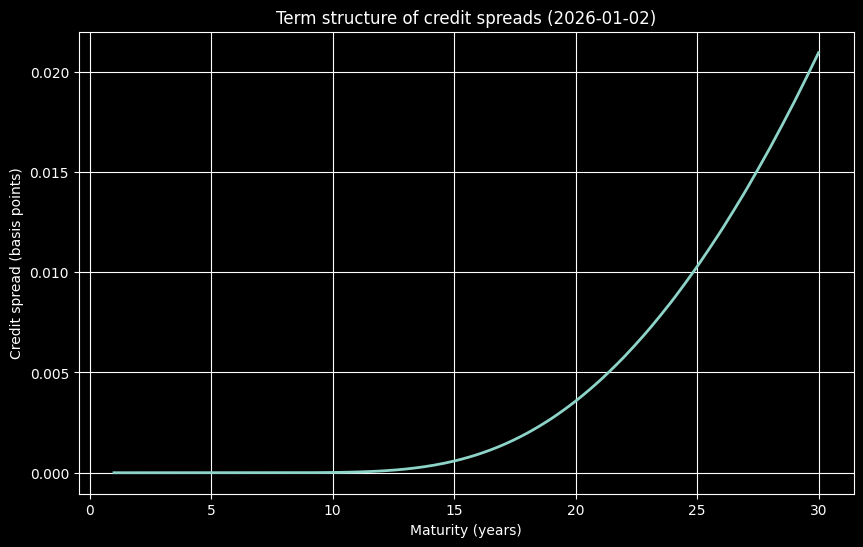

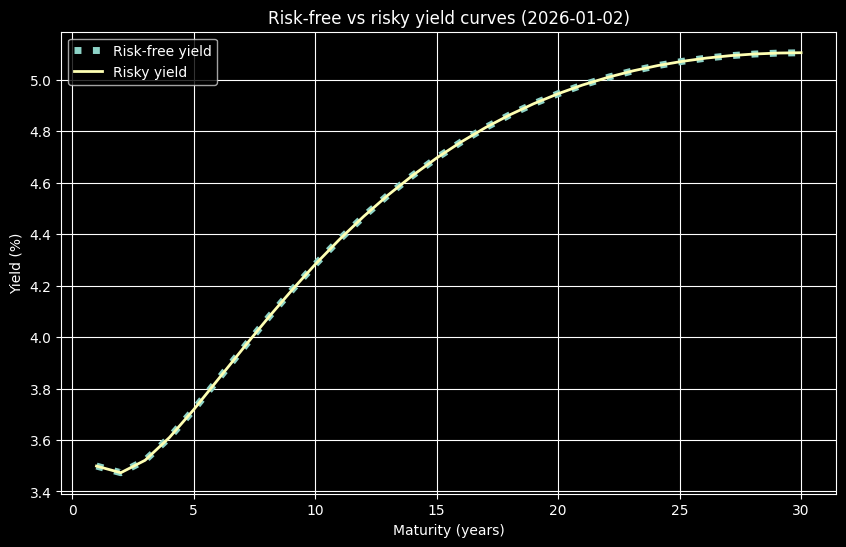

In [18]:
# plot

plt.figure(figsize=(10, 6))
plt.plot(q5_df["maturity_years"], q5_df["credit_spread"] * 10000, linewidth=2)
plt.xlabel("Maturity (years)")
plt.ylabel("Credit spread (basis points)")
plt.title(f"Term structure of credit spreads ({curve_date.date()})")
plt.grid(True)
plt.show()


# risky vs risk-free yield curves

plt.figure(figsize=(10, 6))
plt.plot(q5_df["maturity_years"], q5_df["riskfree_yield"] * 100, linewidth=5, linestyle='dotted', label="Risk-free yield")
plt.plot(q5_df["maturity_years"], q5_df["risky_yield"] * 100, linewidth=2, label="Risky yield")
plt.xlabel("Maturity (years)")
plt.ylabel("Yield (%)")
plt.title(f"Risk-free vs risky yield curves ({curve_date.date()})")
plt.legend()
plt.grid(True)
plt.show()


# save outputs
q5_df.to_csv("q5_credit_spread_term_structure.csv", index=False)
curve.to_csv("q5_riskfree_curve_used.csv", index=False)



# Part 2

In [19]:
# package
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.optimize import brentq


1] Download from the St-Louis Fed website the Nelson-Siegel-Svensson function estimated on
February 27, 2026. Use these risk-free zero-coupon yields 𝑧𝑐𝑦(𝑡) to construct the credit spreads
for the 11 maturities. Plot the three term structures: risk-free, AA yields, and credit spreads.

In [20]:
# input AA yields 
maturity = np.array([0.5, 1, 2, 3, 4, 5, 7, 10, 15, 20, 30], dtype=float)
aa_yield = np.array([3.76, 3.79, 3.86, 3.96, 4.08, 4.20, 4.52, 4.83, 5.42, 5.69, 6.01], dtype=float)


# import data
# Reuse the Federal Reserve nominal zero-coupon dataset downloaded above
df = read_fed_nominal_curve_csv(FED_LOCAL_CSV)

print("First 5 rows:")
print(df.head())


First 5 rows:
        date     BETA0     BETA1     BETA2  BETA3      TAU1    TAU2  SVENY01  \
0 1961-06-14  3.917606 -1.277955 -1.949397    0.0  0.339218 -999.99   2.9825   
1 1961-06-15  3.978498 -1.257404 -2.247617    0.0  0.325775 -999.99   2.9941   
2 1961-06-16  3.984350 -1.429538 -1.885024    0.0  0.348817 -999.99   3.0012   
3 1961-06-19  4.004379 -0.723311 -3.310743    0.0  0.282087 -999.99   2.9949   
4 1961-06-20  3.985789 -0.900432 -2.844809    0.0  0.310316 -999.99   2.9833   

   SVENY02  SVENY03  ...  SVENY21  SVENY22  SVENY23  SVENY24  SVENY25  \
0   3.3771   3.5530  ...      NaN      NaN      NaN      NaN      NaN   
1   3.4137   3.5981  ...      NaN      NaN      NaN      NaN      NaN   
2   3.4142   3.5994  ...      NaN      NaN      NaN      NaN      NaN   
3   3.4386   3.6252  ...      NaN      NaN      NaN      NaN      NaN   
4   3.4101   3.5986  ...      NaN      NaN      NaN      NaN      NaN   

   SVENY26  SVENY27  SVENY28  SVENY29  SVENY30  
0      NaN      N

In [21]:
# keep the row for Feb 27th
row = df.loc[df["date"] == pd.Timestamp("2026-02-27")].iloc[0]
#.iloc[] extract the single row

# NSS parameters
beta0 = float(row["BETA0"])
beta1 = float(row["BETA1"])
beta2 = float(row["BETA2"])
beta3 = float(row["BETA3"])
tau1  = float(row["TAU1"])
tau2  = float(row["TAU2"])

print("Fed NSS parameters on Feb 27 2026")
print(f"beta0 = {beta0:.6f}")
print(f"beta1 = {beta1:.6f}")
print(f"beta2 = {beta2:.6f}")
print(f"beta3 = {beta3:.6f}")
print(f"tau1  = {tau1:.6f}")
print(f"tau2  = {tau2:.6f}")

Fed NSS parameters on Feb 27 2026
beta0 = 1.615248
beta1 = 2.172234
beta2 = -0.000000
beta3 = 10.475890
tau1  = 1.459293
tau2  = 16.868434


Results:
    Maturity (years)  Risk-free zcy (%)  AA yield (%)  Credit spread (%)
0                0.5             3.6067          3.76             0.1533
1                1.0             3.4862          3.79             0.3038
2                2.0             3.3717          3.86             0.4883
3                3.0             3.3648          3.96             0.5952
4                4.0             3.4187          4.08             0.6613
5                5.0             3.5060          4.20             0.6940
6                7.0             3.7207          4.52             0.7993
7               10.0             4.0444          4.83             0.7856
8               15.0             4.4605          5.42             0.9595
9               20.0             4.7087          5.69             0.9813
10              30.0             4.8471          6.01             1.1629


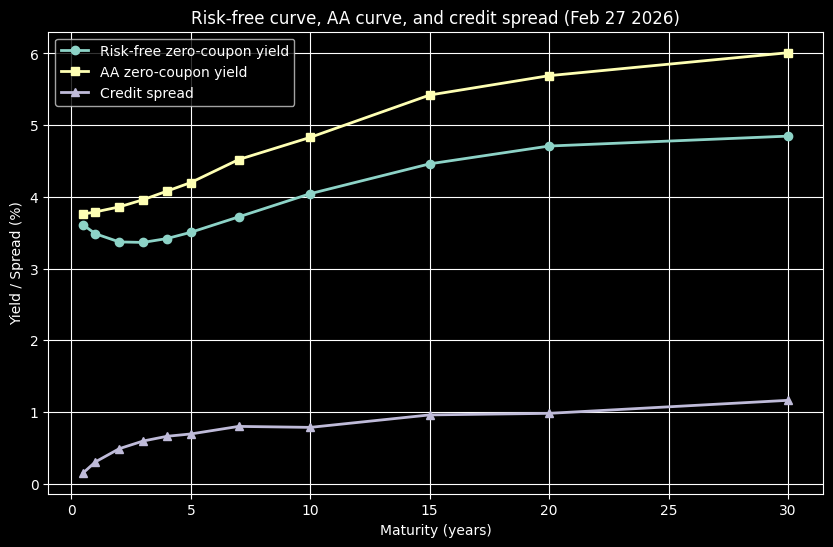

In [22]:

# NSS
def zcy_nss(T, beta0, beta1, beta2, beta3, tau1, tau2):
    T = np.asarray(T, dtype=float)

    x1 = T / tau1
    x2 = T / tau2

    L1 = (1 - np.exp(-x1)) / x1
    L2 = L1 - np.exp(-x1)
    L3 = (1 - np.exp(-x2)) / x2 - np.exp(-x2)

    return beta0 + beta1 * L1 + beta2 * L2 + beta3 * L3

# yield
rf_yield = zcy_nss(maturity, beta0, beta1, beta2, beta3, tau1, tau2)

# credit spreads
credit_spread = aa_yield - rf_yield


# result
result = pd.DataFrame({
    "Maturity (years)": maturity,
    "Risk-free zcy (%)": np.round(rf_yield, 4),
    "AA yield (%)": np.round(aa_yield, 4),
    "Credit spread (%)": np.round(credit_spread, 4)
})

print("Results:")
print(result)


# plot
plt.figure(figsize=(10, 6))
plt.plot(maturity, rf_yield, marker="o", linewidth=2, label="Risk-free zero-coupon yield")
plt.plot(maturity, aa_yield, marker="s", linewidth=2, label="AA zero-coupon yield")
plt.plot(maturity, credit_spread, marker="^", linewidth=2, label="Credit spread")

plt.xlabel("Maturity (years)")
plt.ylabel("Yield / Spread (%)")
plt.title("Risk-free curve, AA curve, and credit spread (Feb 27 2026)")
plt.grid(True)
plt.legend()
plt.show()

2]Check the quality of the fit by plotting on the same graph the AA yields and the continuous
function 𝑌(𝑡) for maturities ranging from 0 to 30 years

In [23]:
# CIR function

def cir_A_B(kappa, theta, sigma, T):
    T = np.asarray(T, dtype=float)

    gamma = np.sqrt(kappa**2 + 2 * sigma**2)

    exp_gamma_T = np.exp(gamma * T)

    B = 2 * (exp_gamma_T - 1) / ((gamma + kappa) * (exp_gamma_T - 1) + 2 * gamma)

    A = (
        2 * gamma * np.exp((kappa + gamma) * T / 2)
        / ((gamma + kappa) * (exp_gamma_T - 1) + 2 * gamma)
    ) ** (2 * kappa * theta / sigma**2)

    return A, B


def cir_price(r0, kappa, theta, sigma, T):
    A, B = cir_A_B(kappa, theta, sigma, T)
    return A * np.exp(-B * r0)


def cir_yield(r0, kappa, theta, sigma, T):
    P = cir_price(r0, kappa, theta, sigma, T)
    return -np.log(P) / T


# fit risk-free CIR curve

def objective_rf(params, T, y_obs):
    r0, kappa_r, theta_r, sigma_r = params

    # positivity check
    if (r0 <= 0) or (kappa_r <= 0) or (theta_r <= 0) or (sigma_r <= 0):
        return 1e10

    y_fit = cir_yield(r0, kappa_r, theta_r, sigma_r, T)
    sse = np.sum((y_obs - y_fit) ** 2)
    return sse


# initial guess
x0_rf = np.array([0.035, 0.50, 0.05, 0.10], dtype=float)

# bounds
bounds_rf = [
    (1e-6, 0.20),   # r0
    (1e-4, 5.00),   # kappa_r
    (1e-6, 0.20),   # theta_r
    (1e-4, 1.00)    # sigma_r
]

res_rf = minimize(
    objective_rf,
    x0_rf,
    args=(maturity, rf_yield / 100),   # convert % to decimals
    method="L-BFGS-B",
    bounds=bounds_rf
)

r0, kappa_r, theta_r, sigma_r = res_rf.x

print("Risk-free CIR calibration")
print("Success:", res_rf.success)
print("Message:", res_rf.message)
print(f"r0      = {r0:.6f}")
print(f"kappa_r = {kappa_r:.6f}")
print(f"theta_r = {theta_r:.6f}")
print(f"sigma_r = {sigma_r:.6f}")

Risk-free CIR calibration
Success: True
Message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
r0      = 0.032813
kappa_r = 0.043014
theta_r = 0.071379
sigma_r = 0.001898


In [24]:
# fit
rf_fit = cir_yield(r0, kappa_r, theta_r, sigma_r, maturity) * 100

rf_table = pd.DataFrame({
    "Maturity": maturity,
    "Observed rf yield (%)": np.round(rf_yield, 4),
    "Fitted rf yield (%)": np.round(rf_fit, 4),
    "Error": np.round(rf_yield - rf_fit, 6)
})

print("Risk-free fit table")
print(rf_table)

Risk-free fit table
    Maturity  Observed rf yield (%)  Fitted rf yield (%)     Error
0        0.5                 3.6067               3.3225  0.284188
1        1.0                 3.4862               3.3631  0.123112
2        2.0                 3.3717               3.4425 -0.070792
3        3.0                 3.3648               3.5198 -0.154970
4        4.0                 3.4187               3.5948 -0.176075
5        5.0                 3.5060               3.6678 -0.161805
6        7.0                 3.7207               3.8077 -0.086987
7       10.0                 4.0444               4.0034  0.040969
8       15.0                 4.4605               4.2957  0.164840
9       20.0                 4.7087               4.5509  0.157845
10      30.0                 4.8471               4.9706 -0.123497


In [25]:
# Duffee defaultable curve to AA yields
def duffee_yield(T, r0, kappa_r, theta_r, sigma_r,
                 s0, kappa_s, theta_s, sigma_s, alpha, beta):
   
    if 1 + beta <= 0:
        # invalid because sqrt(1+beta) is not defined in reals
        return np.full_like(np.asarray(T, dtype=float), 1e6)

    x0 = (1 + beta) * r0
    kappa_x = kappa_r
    theta_x = (1 + beta) * theta_r
    sigma_x = np.sqrt(1 + beta) * sigma_r

    y_x = cir_yield(x0, kappa_x, theta_x, sigma_x, T)
    y_s = cir_yield(s0, kappa_s, theta_s, sigma_s, T)

    return alpha + y_x + y_s


def objective_aa(params, T, y_obs, r0, kappa_r, theta_r, sigma_r):

    s0, kappa_s, theta_s, sigma_s, alpha, beta = params

    # positivity / admissibility checks
    if (s0 <= 0) or (kappa_s <= 0) or (theta_s <= 0) or (sigma_s <= 0):
        return 1e10

    if 1.0 + beta <= 0:
        return 1e10

    y_fit = duffee_yield(
        T,
        r0, kappa_r, theta_r, sigma_r,
        s0, kappa_s, theta_s, sigma_s, alpha, beta
    )

    sse = np.sum((y_obs - y_fit) ** 2)
    return sse


# initial guess
x0_aa = np.array([0.005, 0.50, 0.01, 0.10, 0.001, 0.20], dtype=float)

# bounds
bounds_aa = [
    (1e-6, 0.10),   # s0
    (1e-4, 5.00),   # kappa_s
    (1e-6, 0.20),   # theta_s
    (1e-4, 1.00),   # sigma_s
    (0.00, 0.10),   # alpha
    (-0.99, 5.00)   # beta
]

res_aa = minimize(
    objective_aa,
    x0_aa,
    args=(maturity, aa_yield / 100, r0, kappa_r, theta_r, sigma_r),
    method="L-BFGS-B",
    bounds=bounds_aa
)

s0, kappa_s, theta_s, sigma_s, alpha, beta = res_aa.x

print("Duffee defaultable calibration")
print(f"s0      = {s0:.6f}")
print(f"kappa_s = {kappa_s:.6f}")
print(f"theta_s = {theta_s:.6f}")
print(f"sigma_s = {sigma_s:.6f}")
print(f"alpha   = {alpha:.6f}")
print(f"beta    = {beta:.6f}")

Duffee defaultable calibration
s0      = 0.000001
kappa_s = 0.496495
theta_s = 0.007594
sigma_s = 0.101794
alpha   = 0.000000
beta    = 0.063852


In [26]:
# fit AA
aa_fit = duffee_yield(
    maturity,
    r0, kappa_r, theta_r, sigma_r,
    s0, kappa_s, theta_s, sigma_s, alpha, beta
) * 100

aa_table = pd.DataFrame({
    "Maturity": maturity,
    "Observed AA yield (%)": np.round(aa_yield, 4),
    "Fitted AA yield (%)": np.round(aa_fit, 4),
    "Error": np.round(aa_yield - aa_fit, 6)
})

print("AA fit table")
print(aa_table)

AA fit table
    Maturity  Observed AA yield (%)  Fitted AA yield (%)     Error
0        0.5                   3.76               3.6216  0.138379
1        1.0                   3.79               3.7386  0.051381
2        2.0                   3.86               3.9398 -0.079759
3        3.0                   3.96               4.1076 -0.147620
4        4.0                   4.08               4.2514 -0.171404
5        5.0                   4.20               4.3775 -0.177479
6        7.0                   4.52               4.5929 -0.072880
7       10.0                   4.83               4.8586 -0.028614
8       15.0                   5.42               5.2172  0.202802
9       20.0                   5.69               5.5129  0.177126
10      30.0                   6.01               5.9836  0.026431


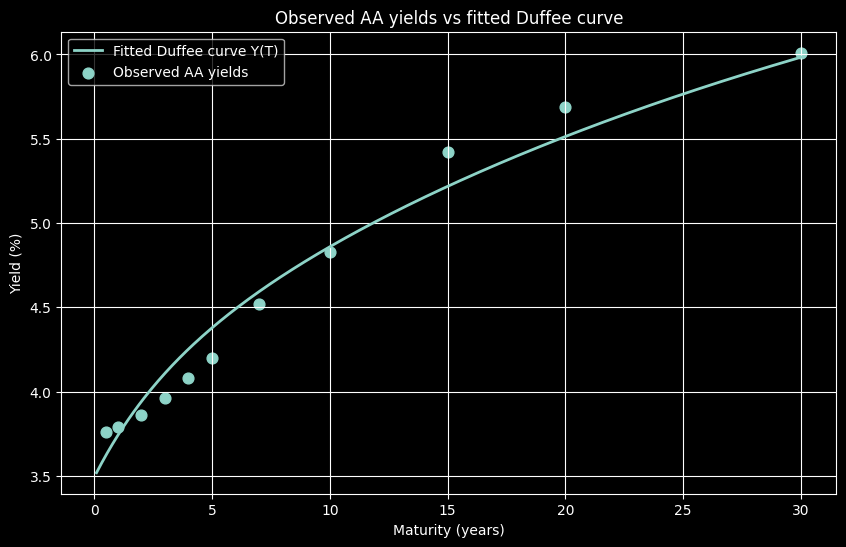

In [27]:
# plot

T_grid = np.linspace(0.1, 30, 400)

aa_curve = duffee_yield(
    T_grid,
    r0, kappa_r, theta_r, sigma_r,
    s0, kappa_s, theta_s, sigma_s, alpha, beta
) * 100.0

plt.figure(figsize=(10, 6))
plt.plot(T_grid, aa_curve, linewidth=2, label="Fitted Duffee curve Y(T)")
plt.scatter(maturity, aa_yield, s=60, label="Observed AA yields")
plt.xlabel("Maturity (years)")
plt.ylabel("Yield (%)")
plt.title("Observed AA yields vs fitted Duffee curve")
plt.grid(True)
plt.legend()
plt.show()



3] Use the calibrated Duffee (1999) model to evaluate the following AA corporate bond issue:
• Nominal: $1,000,000.
• Maturity: 5 years.
• Coupon rate: 4% paid semi-annually.
• Callable at par at anytime.
Use the explicit finite difference scheme in two dimensions (for 𝑟 𝑡 and 𝑠𝑡).

In [28]:
# bond inputs
F = 1_000_000         # nominal
coupon_rate = 0.04       # annual coupon rate
coupon = F * coupon_rate / 2  # semiannual coupon = 20,000
T_mat = 5            # maturity

coupon_dates = np.array([0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0])

# grid settings
Nr = 160
Ns = 160
Nt = 8000


# upper bounds for state variables
r_max = max(0.20, 4 * max(r0, theta_r))
s_max = max(0.20, 4 * max(s0, theta_s))

r_grid = np.linspace(0, r_max, Nr + 1)
s_grid = np.linspace(0, s_max, Ns + 1)

dr = r_grid[1] - r_grid[0]
ds = s_grid[1] - s_grid[0]
dt = T_mat / Nt

print("Grid info:")
print(f"Nr = {Nr}, Ns = {Ns}, Nt = {Nt}")
print(f"dr = {dr:.6f}, ds = {ds:.6f}, dt = {dt:.6f}")
print(f"r_max = {r_max:.6f}, s_max = {s_max:.6f}")

Grid info:
Nr = 160, Ns = 160, Nt = 8000
dr = 0.001784, ds = 0.001250, dt = 0.000625
r_max = 0.285516, s_max = 0.200000


In [29]:

# terminal condition at maturity

# at T: principal + final coupon
V_next = np.full((Nr + 1, Ns + 1), F + coupon, dtype=float)


# check if a time is a coupon date
def is_coupon_time(t, coupon_dates, tol):
    return np.any(np.abs(coupon_dates - t) < tol)

tol_coupon = dt / 2


# Bilinear interpolation helper -> find the position of x and y

def bilinear_interp(x, y, x_grid, y_grid, V):
    # find x bracket
    i = np.searchsorted(x_grid, x) - 1
    j = np.searchsorted(y_grid, y) - 1

    i = max(0, min(i, len(x_grid) - 2))
    j = max(0, min(j, len(y_grid) - 2))

    x1, x2 = x_grid[i], x_grid[i+1]
    y1, y2 = y_grid[j], y_grid[j+1]

    Q11 = V[i, j]
    Q12 = V[i, j+1]
    Q21 = V[i+1, j]
    Q22 = V[i+1, j+1]

    if (x2 - x1) == 0 or (y2 - y1) == 0:
        return V[i, j]

    wx = (x - x1) / (x2 - x1)
    wy = (y - y1) / (y2 - y1)

    return ((1-wx)*(1-wy)*Q11 +
            (1-wx)*wy*Q12 +
            wx*(1-wy)*Q21 +
            wx*wy*Q22)


########################################
#  Backward explicit finite difference #
########################################

# create 2D state grids 
R, S = np.meshgrid(r_grid, s_grid, indexing="ij")

# interior grids 
R_in = R[:-1, :-1]
S_in = S[:-1, :-1]


def accrued_interest(t, coupon, period=0.5):
    if t <= 1e-14:
        return 0.0
    prev_coupon = np.floor((t - 1e-14) / period) * period
    return coupon * (t - prev_coupon) / period




for n in range(Nt - 1, -1, -1): # -1 -> start at the last time
    t = n * dt

    # initialize current value surface
    V = np.zeros_like(V_next)

 
    # finite differences on interior points
    # first & second derivatives in r
    Vr = np.zeros_like(V_next)
    Vrr = np.zeros_like(V_next)

    Vr[1:Nr, :] = (V_next[2:Nr+1, :] - V_next[0:Nr-1, :]) / (2 * dr)
    Vrr[1:Nr, :] = (V_next[2:Nr+1, :] - 2 * V_next[1:Nr, :] + V_next[0:Nr-1, :]) / dr**2

    # one-sided at r = 0
    Vr[0, :] = (V_next[1, :] - V_next[0, :]) / dr
    Vrr[0, :] = (V_next[2, :] - 2 * V_next[1, :] + V_next[0, :]) / dr**2

    # first & second derivatives in s
    Vs = np.zeros_like(V_next)
    Vss = np.zeros_like(V_next)

    Vs[:, 1:Ns] = (V_next[:, 2:Ns+1] - V_next[:, 0:Ns-1]) / (2 * ds)
    Vss[:, 1:Ns] = (V_next[:, 2:Ns+1] - 2 * V_next[:, 1:Ns] + V_next[:, 0:Ns-1]) / ds**2

    # one-sided at s = 0
    Vs[:, 0] = (V_next[:, 1] - V_next[:, 0]) / ds
    Vss[:, 0] = (V_next[:, 2] - 2 * V_next[:, 1] + V_next[:, 0]) / ds**2

    
    # PDE coefficients
    mu_r = kappa_r * (R - theta_r * 0 + theta_r - R)   # same as kappa_r*(theta_r - R)
    mu_r = kappa_r * (theta_r - R)

    mu_s = kappa_s * (theta_s - S)

    var_r = 0.5 * sigma_r**2 * R
    var_s = 0.5 * sigma_s**2 * S

    disc = alpha + (1 + beta) * R + S

    # PDE operator
    LV = mu_r * Vr + var_r * Vrr + mu_s * Vs + var_s * Vss - disc * V_next

    # backward explicit update
    V[:-1, :-1] = V_next[:-1, :-1] + dt * LV[:-1, :-1]


    # boundary conditions: high r or s -> low bond value
    V[Nr, :] = 0  
    V[:, Ns] = 0 

    # keep values nonnegative
    V = np.maximum(V, 0)

 
    # coupon & callability
    if is_coupon_time(t + dt, coupon_dates[:-1], tol_coupon):
        V = V + coupon
    K_t = F + accrued_interest(t, coupon, period=0.5)
    V = np.minimum(V, K_t)

    # move backward one step
    V_next = V.copy()


# Price at t=0, r=r0, s=s0

callable_price = bilinear_interp(r0, s0, r_grid, s_grid, V_next)

print(f"Callable bond price = ${callable_price:,.2f}")



Callable bond price = $982,085.24


4] Compute the yield-to-maturity on the callable bond. Compare it with the yield-to-maturity on
the similar non-callable bond issue (use the closed-form solution).

In [30]:

# Closed-form
def duffee_zcb_price(T, r0, kappa_r, theta_r, sigma_r,
                     s0, kappa_s, theta_s, sigma_s, alpha, beta):

    T = np.asarray(T, dtype=float)

    # x_t = (1+beta) r_t
    x0 = (1 + beta) * r0
    kappa_x = kappa_r
    theta_x = (1 + beta) * theta_r
    sigma_x = np.sqrt(1 + beta) * sigma_r

    Px = cir_price(x0, kappa_x, theta_x, sigma_x, T)
    Ps = cir_price(s0, kappa_s, theta_s, sigma_s, T)

    return np.exp(-alpha * T) * Px * Ps


# Non-callable bond price
zcb_prices = duffee_zcb_price(
    coupon_dates,
    r0, kappa_r, theta_r, sigma_r,
    s0, kappa_s, theta_s, sigma_s, alpha, beta
)

cashflows = np.full(len(coupon_dates), coupon, dtype=float)
cashflows[-1] = coupon + F

noncallable_price = np.sum(cashflows * zcb_prices)

print(f"Non-callable bond price = ${noncallable_price:,.2f}")
print(f"Callable bond price     = ${callable_price:,.2f}")

Non-callable bond price = $982,146.65
Callable bond price     = $982,085.24


In [31]:

# YTM (semi)

def bond_price_from_ytm(y, cashflows, times):
    return np.sum(cashflows / (1 + y / 2) ** (2 * times))


def f_callable_ytm(y):
    return bond_price_from_ytm(y, cashflows, coupon_dates) - callable_price


def f_noncallable_ytm(y):
    return bond_price_from_ytm(y, cashflows, coupon_dates) - noncallable_price


callable_ytm = brentq(f_callable_ytm, 1e-6, 1)
noncallable_ytm = brentq(f_noncallable_ytm, 1e-6, 1)

print(f"Callable bond YTM       = {100 * callable_ytm:.4f}%")
print(f"Non-callable bond YTM   = {100 * noncallable_ytm:.4f}%")
print(f"YTM difference          = {100 * (callable_ytm - noncallable_ytm):.4f}%")
print(f"Price difference        = ${noncallable_price - callable_price:,.2f}")

Callable bond YTM       = 4.4031%
Non-callable bond YTM   = 4.4017%
YTM difference          = 0.0014%
Price difference        = $61.41
